In [32]:
from langgraph.graph import StateGraph
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [33]:
load_dotenv()

True

In [34]:
model = ChatOpenAI()

In [35]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    feedback: str
    
    

In [36]:
def create_outline(state: BlogState) -> BlogState:
    # Title
    title = state['title']
    
    prompt = f"create an outline for a blog post with the title: {title}"
    
    result =model.invoke(prompt).content
    
    # Update the state
    state['outline'] = result
    
    return state

    
    
    
    

In [37]:
def create_blog(state: BlogState)-> BlogState:
    
    title = state['title']
    
    outline = state['outline']
    
    prompt = f'Write a detailed blog post with the title: {title} and the following outline: {outline}'
    
    result = model.invoke(prompt).content
    
    # Updatingg the state
    
    state['content'] = result
    
    return state


In [38]:
def evaluate_blog(state: BlogState) -> BlogState:
    
    title = state['title']
    
    content = state['content']
    
    prompt = f'Evaluate the following blog post with the title: {title} and content: {content}. Provide feedback on how to improve it.'
    
    result = model.invoke(prompt).content
    
    # Update the state with feedback
    state['feedback'] = result
    
    return state

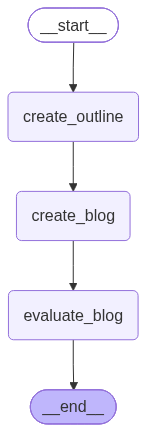

In [39]:
from langgraph.graph import START, END
graph = StateGraph(BlogState)

# nodes 
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluate_blog', evaluate_blog)


graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)

workflow = graph.compile()
workflow



In [40]:
initial_state = {"title": "Future of software engineering after gpt astra"}

final_state = workflow.invoke(initial_state)

final_state

{'title': 'Future of software engineering after gpt astra',
 'outline': 'I. Introduction\n    A. Brief explanation of GPT-3 and its impact on software engineering\n    B. Introduction of GPT Astra and its potential implications for the field\n\nII. Evolution of software engineering with AI\n    A. Overview of how AI has already impacted software engineering\n    B. Comparison of GPT-3 and GPT Astra in terms of capabilities and potential benefits\n    C. Discussion on how GPT Astra could revolutionize software development processes\n\nIII. Potential challenges and ethical concerns\n    A. Addressing concerns about job displacement in the software engineering industry\n    B. Ethical considerations surrounding the use of AI in software development\n    C. Ways to mitigate potential risks and ensure responsible AI usage\n\nIV. Opportunities for innovation and growth\n    A. Exploration of new possibilities for automation and efficiency in software engineering\n    B. Discussion on how GPT

In [41]:
print(final_state['content'])

In recent years, artificial intelligence (AI) has been making significant waves in the field of software engineering. With the introduction of GPT-3 by OpenAI, developers have been able to leverage the power of AI to automate tasks such as natural language processing and text generation. This has revolutionized the way software is developed, enabling faster prototyping and more efficient coding processes.

Now, with the release of GPT Astra, a next-generation AI language model, the future of software engineering is even more exciting and promising. In this blog post, we will explore the evolution of software engineering with AI, the potential implications of GPT Astra on the field, as well as the challenges and opportunities it presents.

Evolution of software engineering with AI

AI has already had a significant impact on software engineering, with tools like GPT-3 enabling developers to automate repetitive tasks and accelerate the coding process. GPT Astra, with its enhanced capabili